In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import func_notebook as nbk
from pathlib import Path
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

In [3]:
#filepaths for cold run ALPINE
filepaths = ['/disk/gfs_atp/hekinc/Master_measurements/alpine_cold/led2.5Vamp-2+3sipm+54temp-90c/RAW/DataR_CH0@DT5730S_63863_led2.5Vamp-2+3sipm+54temp-90c.CSV',
             '/disk/gfs_atp/hekinc/Master_measurements/alpine_cold/led2.5Vamp-2+3sipm+56temp-90c/RAW/DataR_CH0@DT5730S_63863_led2.5Vamp-2+3sipm+56temp-90c.CSV',
             '/disk/gfs_atp/hekinc/Master_measurements/alpine_cold/led2.45Vamp-2+3sipm+56temp-90c/RAW/DataR_CH0@DT5730S_63863_led2.45Vamp-2+3sipm+56temp-90c.CSV',
             '/disk/gfs_atp/hekinc/Master_measurements/alpine_cold/led2.45Vamp-2+3sipm+58temp-90c/RAW/DataR_CH0@DT5730S_63863_led2.45Vamp-2+3sipm+58temp-90c.CSV',
             '/disk/gfs_atp/hekinc/Master_measurements/alpine_cold/led2.56Vamp-2+3sipm+52temp-90c/RAW/DataR_CH0@DT5730S_63863_led2.56Vamp-2+3sipm+52temp-90c.CSV',
             '/disk/gfs_atp/hekinc/Master_measurements/alpine_cold/led2.56Vamp-2+3sipm+54temp-90c/RAW/DataR_CH0@DT5730S_63863_led2.56Vamp-2+3sipm+54temp-90c.CSV',
             '/disk/gfs_atp/hekinc/Master_measurements/alpine_cold/maybe_bad_data_led2.5Va,p-2+3sipm+48temp-90c/RAW/DataR_CH0@DT5730S_63863_led2.5Va,p-2+3sipm+48temp-90c.CSV'
]


Total events: 120146
Rejected by Pile-up (Found >1 peak): 0
Rejected by bad window length: 0
Successfully integrated: 120146


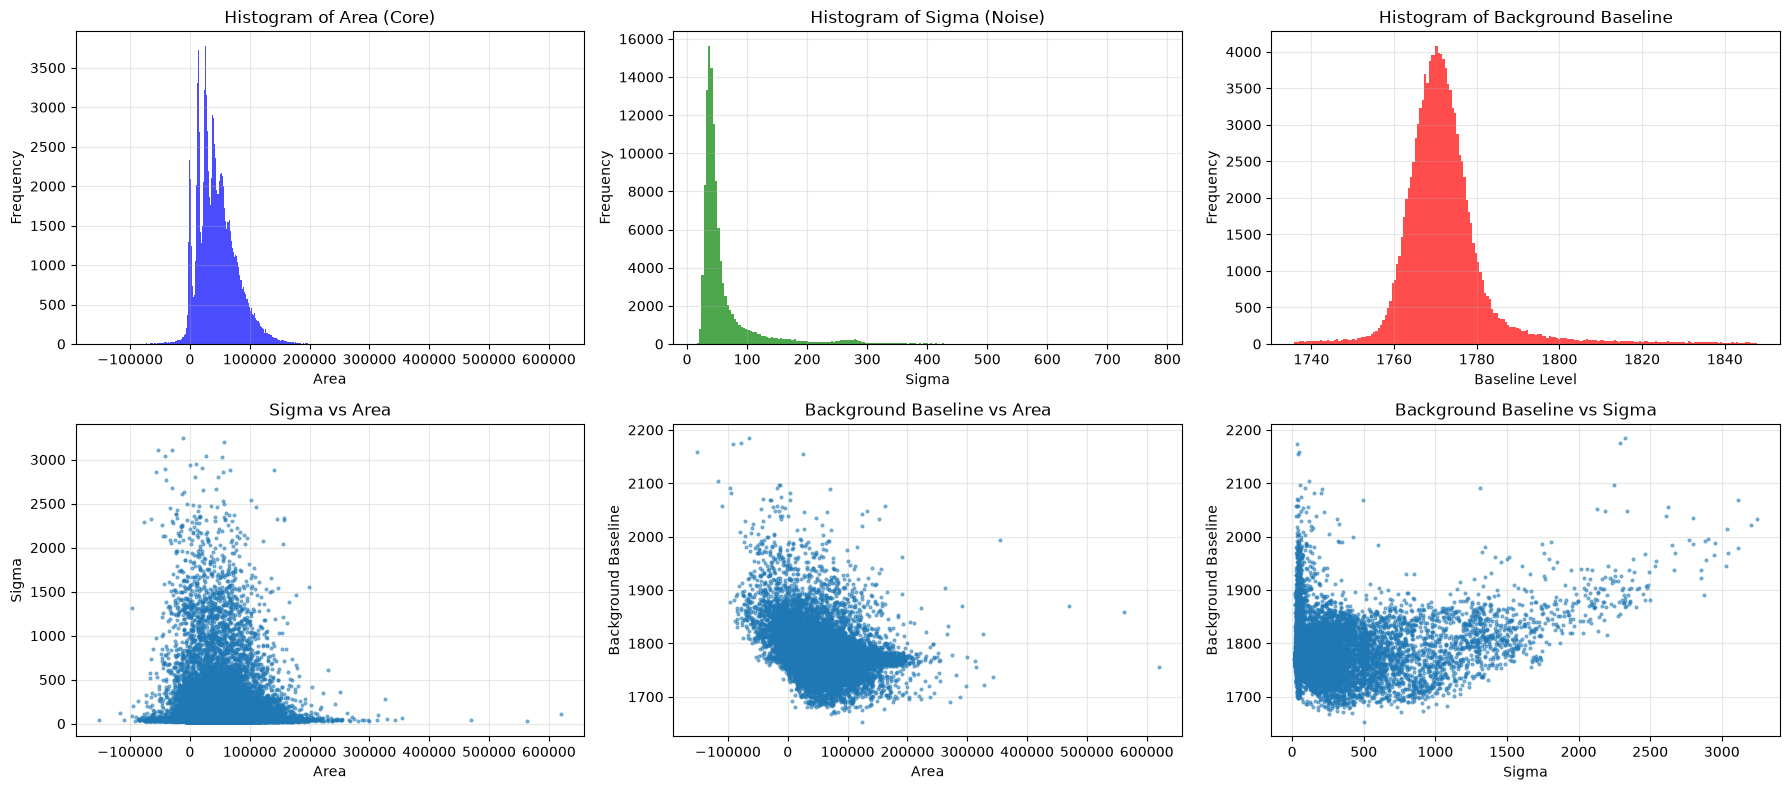

Processing 120146 data points...
Auto-detecting peaks...
Physics Curve fitting converged successfully!

--- Physical Fit Results ---
Pedestal (μ_0): -1.565433e+02
Detector Gain:      1.391332e+04
Pedestal Noise (σ_0): 1.545925e+03
1-Photon Noise (σ_1): 7.729624e+02
χ² / NDF:           55246553.09 / 201 = 274858.473
----------------------------
Peak 0: μ = -1.565433e+02, σ = 1.545925e+03
Peak 1: μ = 1.375678e+04, σ = 1.728397e+03
Peak 2: μ = 2.767010e+04, σ = 1.893364e+03


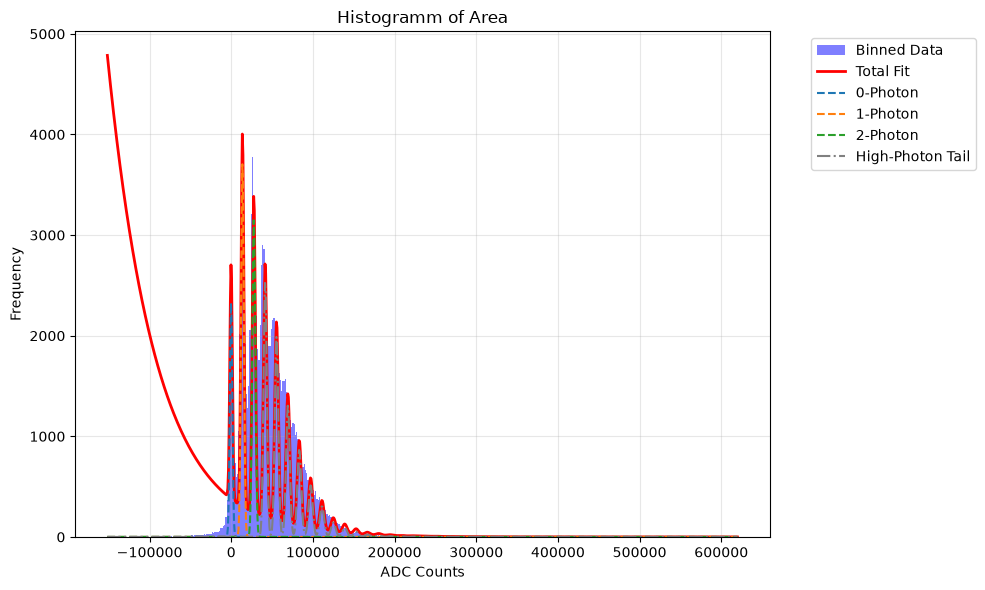

(array([ 3.77299998e+02,  1.67509184e-05, -1.56543347e+02,  1.54592484e+03,
         1.39133236e+04,  7.72962421e+02,  2.33600000e+03,  3.72100000e+03,
         3.16100000e+03,  2.53600000e+03,  1.99600000e+03,  1.31000000e+03,
         8.68000000e+02,  5.15000000e+02,  3.05000000e+02,  1.45000000e+02,
         9.20000000e+01,  5.20000000e+01,  2.40000000e+01,  1.60000000e+01,
         8.00000000e+00,  4.00000000e+00,  3.00000000e+00,  2.00000000e+00,
         2.00000000e+00,  1.00000000e-10,  1.00000000e-10,  1.00000000e-10,
         1.00000000e-10,  1.00000000e-10,  1.00000000e-10,  1.00000000e-10,
         1.00000000e-10,  1.00000000e-10,  1.00000000e-10,  1.00000000e-10]),
 array([[ 7.17976062e+03, -1.46655044e-04,  7.94625072e+01, ...,
         -6.38610355e+01, -5.11396079e+01, -4.43383480e+01],
        [-1.46655044e-04,  3.14818868e-12, -1.47822993e-06, ...,
          1.35378343e-06,  1.08446574e-06,  9.40561421e-07],
        [ 7.94625072e+01, -1.47822993e-06,  2.18051556e+05, ..

In [4]:
array_area, array_sigma, array_bkg = nbk.compute_DAQ_data(filepaths[0])

nbk.plotter(array_area, array_sigma, array_bkg)

nbk.analyze_and_fit_physics(array_area, num_peaks_to_fit=30, confident_peak_limit=2)

Total events: 120052
Rejected by Pile-up (Found >1 peak): 0
Rejected by bad window length: 0
Successfully integrated: 120052


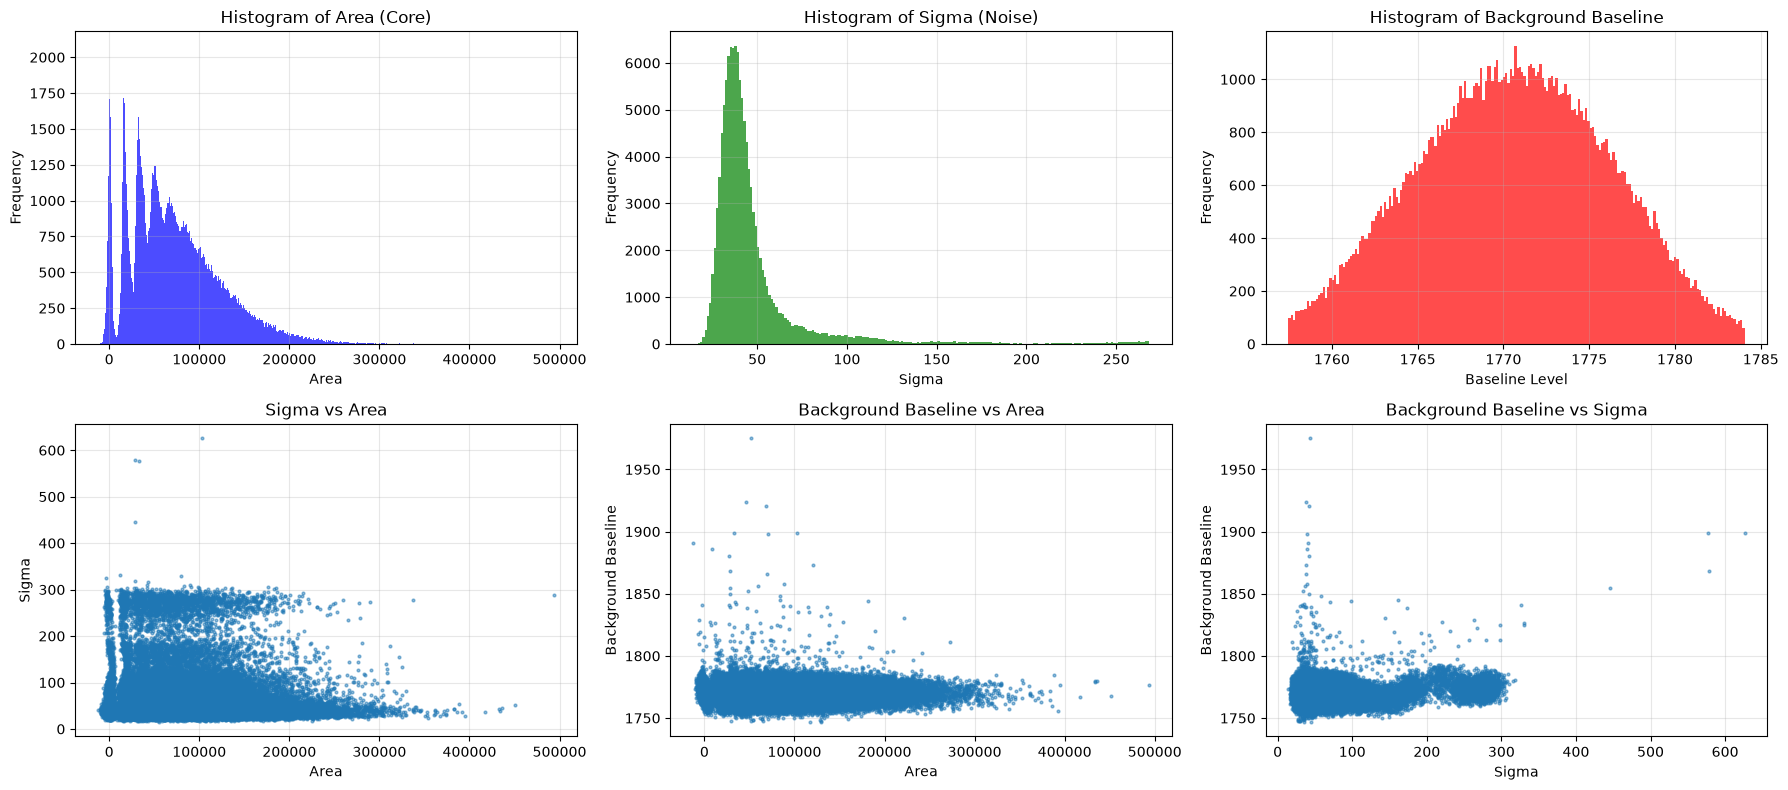

Processing 120052 data points...
Auto-detecting peaks...
Physics Curve fitting converged successfully!

--- Physical Fit Results ---
Pedestal (μ_0): 5.452146e+02
Detector Gain:      1.664997e+04
Pedestal Noise (σ_0): 1.754379e+03
1-Photon Noise (σ_1): 3.027904e+03
χ² / NDF:           2318.25 / 342 = 6.779
----------------------------
Peak 0: μ = 5.452146e+02, σ = 1.754379e+03
Peak 1: μ = 1.719518e+04, σ = 3.499436e+03
Peak 2: μ = 3.384515e+04, σ = 4.627554e+03


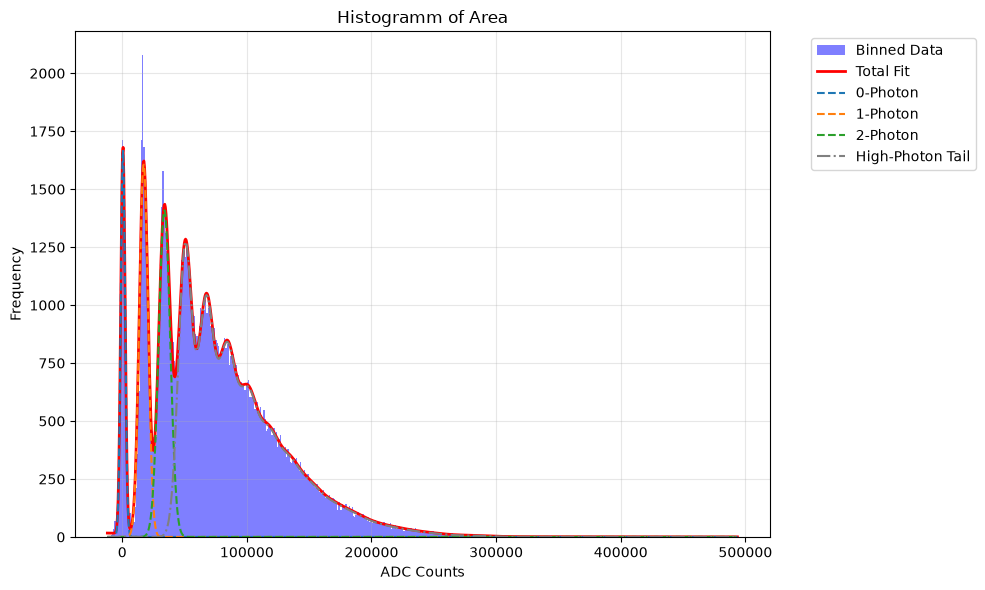

(array([1.51862995e+01, 8.06151043e-06, 5.45214589e+02, 1.75437948e+03,
        1.66499691e+04, 3.02790400e+03, 1.67189385e+03, 1.60867137e+03,
        1.41041105e+03, 1.24049346e+03, 9.82938881e+02, 7.59988571e+02,
        5.56758934e+02, 3.85039645e+02, 2.69489087e+02, 1.74814616e+02,
        1.05930214e+02, 7.53438855e+01, 3.97047257e+01, 2.64339941e+01,
        1.47942053e+01, 9.23837211e+00, 2.36454732e+00, 4.36820999e+00]),
 array([[ 1.74333117e+02,  1.89037047e-05,  2.39799911e+01,
         -2.77700202e+02,  4.58879650e+01, -8.62510967e+01,
         -1.12700043e+02, -1.49020313e+02, -1.13261446e+02,
         -7.83807078e+01, -5.74012601e+01, -4.56114333e+01,
         -3.83276678e+01, -3.23473331e+01, -2.74893276e+01,
         -2.38970505e+01, -1.92569054e+01, -1.68910297e+01,
         -1.31741071e+01, -1.20582640e+01, -7.58811031e+00,
         -1.04467447e+01, -1.51210848e+00, -1.08164093e+01],
        [ 1.89037047e-05,  1.78888156e-10,  1.84984961e-05,
         -2.72857762e-05,

In [5]:
array_area, array_sigma, array_bkg = nbk.compute_DAQ_data(filepaths[1])

nbk.plotter(array_area, array_sigma, array_bkg)

nbk.analyze_and_fit_physics(array_area,num_peaks_to_fit=18, confident_peak_limit = 2)

Total events: 120052
Rejected by Pile-up (Found >1 peak): 0
Rejected by bad window length: 0
Successfully integrated: 120052


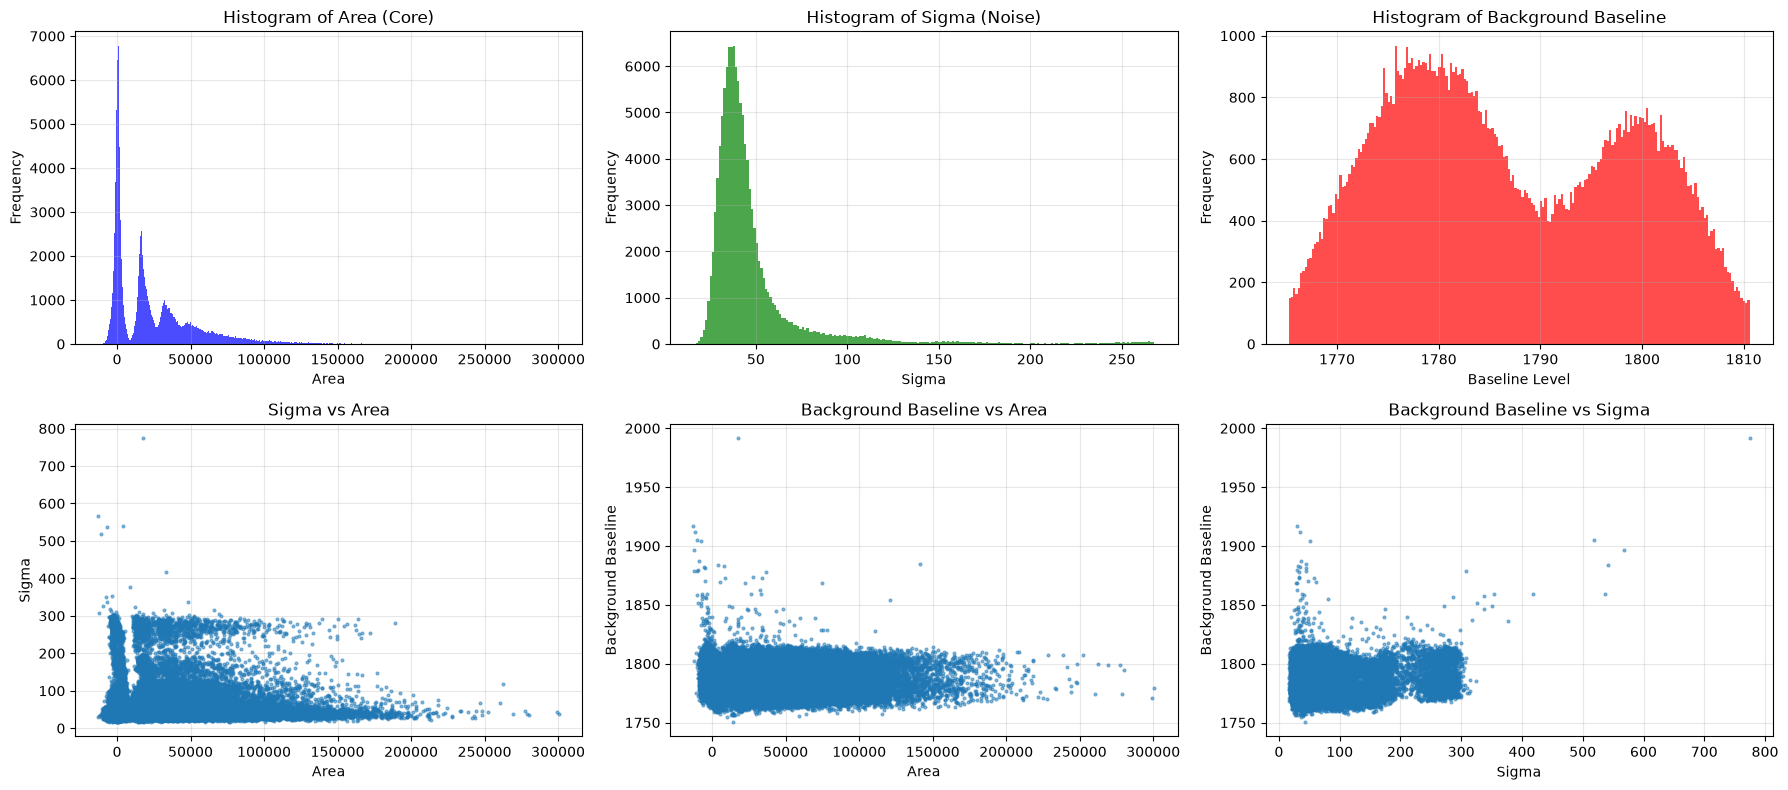

Processing 120052 data points...
Auto-detecting peaks...
Physics Curve fitting converged successfully!

--- Physical Fit Results ---
Pedestal (μ_0): 4.942170e+02
Detector Gain:      1.659843e+04
Pedestal Noise (σ_0): 1.697484e+03
1-Photon Noise (σ_1): 2.686343e+03
χ² / NDF:           90992.99 / 356 = 255.598
----------------------------
Peak 0: μ = 4.942170e+02, σ = 1.697484e+03
Peak 1: μ = 1.709265e+04, σ = 3.177718e+03
Peak 2: μ = 3.369107e+04, σ = 4.161049e+03
Peak 3: μ = 5.028950e+04, σ = 4.952855e+03
Peak 4: μ = 6.688793e+04, σ = 5.634466e+03
Peak 5: μ = 8.348636e+04, σ = 6.242087e+03


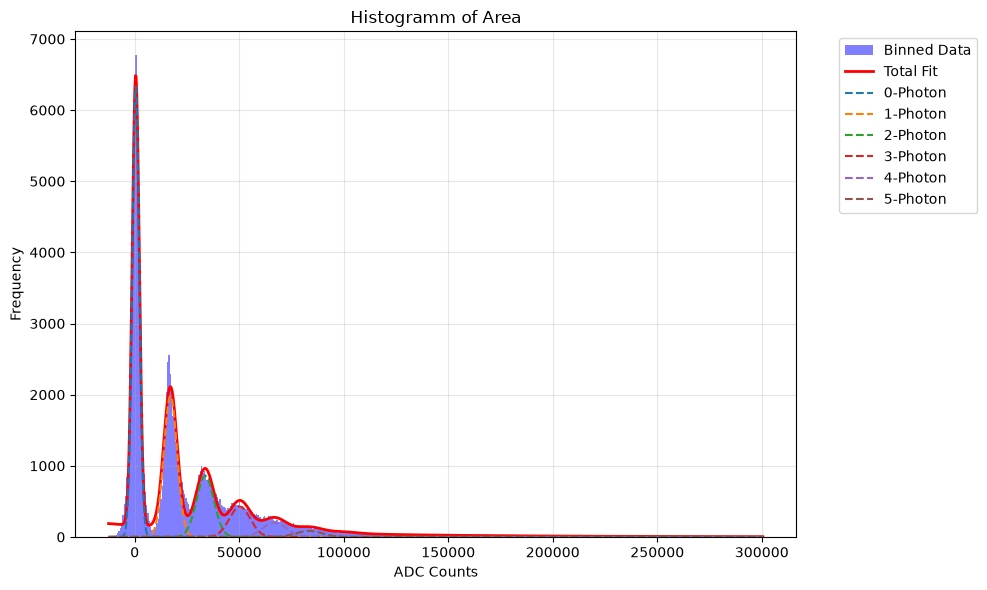

(array([1.60504534e+02, 1.26780774e-05, 4.94217034e+02, 1.69748411e+03,
        1.65984288e+04, 2.68634313e+03, 6.34716177e+03, 1.98354731e+03,
        8.57734835e+02, 4.26159341e+02, 2.02396358e+02, 8.43323020e+01,
        2.58758142e+01, 1.83789799e+00, 2.02357620e-13, 5.80574706e-16,
        9.03161860e-17, 4.55272073e-18, 3.23055000e-18, 5.83935522e-29,
        3.18733797e-29, 2.46346163e-29, 6.35133279e-30, 1.20798504e-32]),
 array([[ 3.94112456e+02, -9.43940578e-05, -1.37829819e+01,
         -1.46396850e+02,  9.29949868e+01, -1.26047669e+03,
         -2.89668912e+02, -3.62770525e+02, -5.81335151e+02,
         -6.30430965e+02, -6.17008977e+02, -5.72510631e+02,
         -5.12047106e+02, -4.44705623e+02, -3.79709085e+02,
         -3.20945467e+02, -2.70113701e+02, -2.27972431e+02,
         -1.88533771e+02, -1.63410491e+02, -1.24080658e+02,
         -1.28478670e+02, -5.86884356e+01, -1.32422076e+02],
        [-9.43940578e-05,  1.19492243e-10,  2.39391300e-05,
          3.34667826e-05,

In [6]:
array_area, array_sigma, array_bkg = nbk.compute_DAQ_data(filepaths[2])

nbk.plotter(array_area, array_sigma, array_bkg)

nbk.analyze_and_fit_physics(array_area, num_peaks_to_fit=18)



Total events: 120065
Rejected by Pile-up (Found >1 peak): 0
Rejected by bad window length: 0
Successfully integrated: 120065


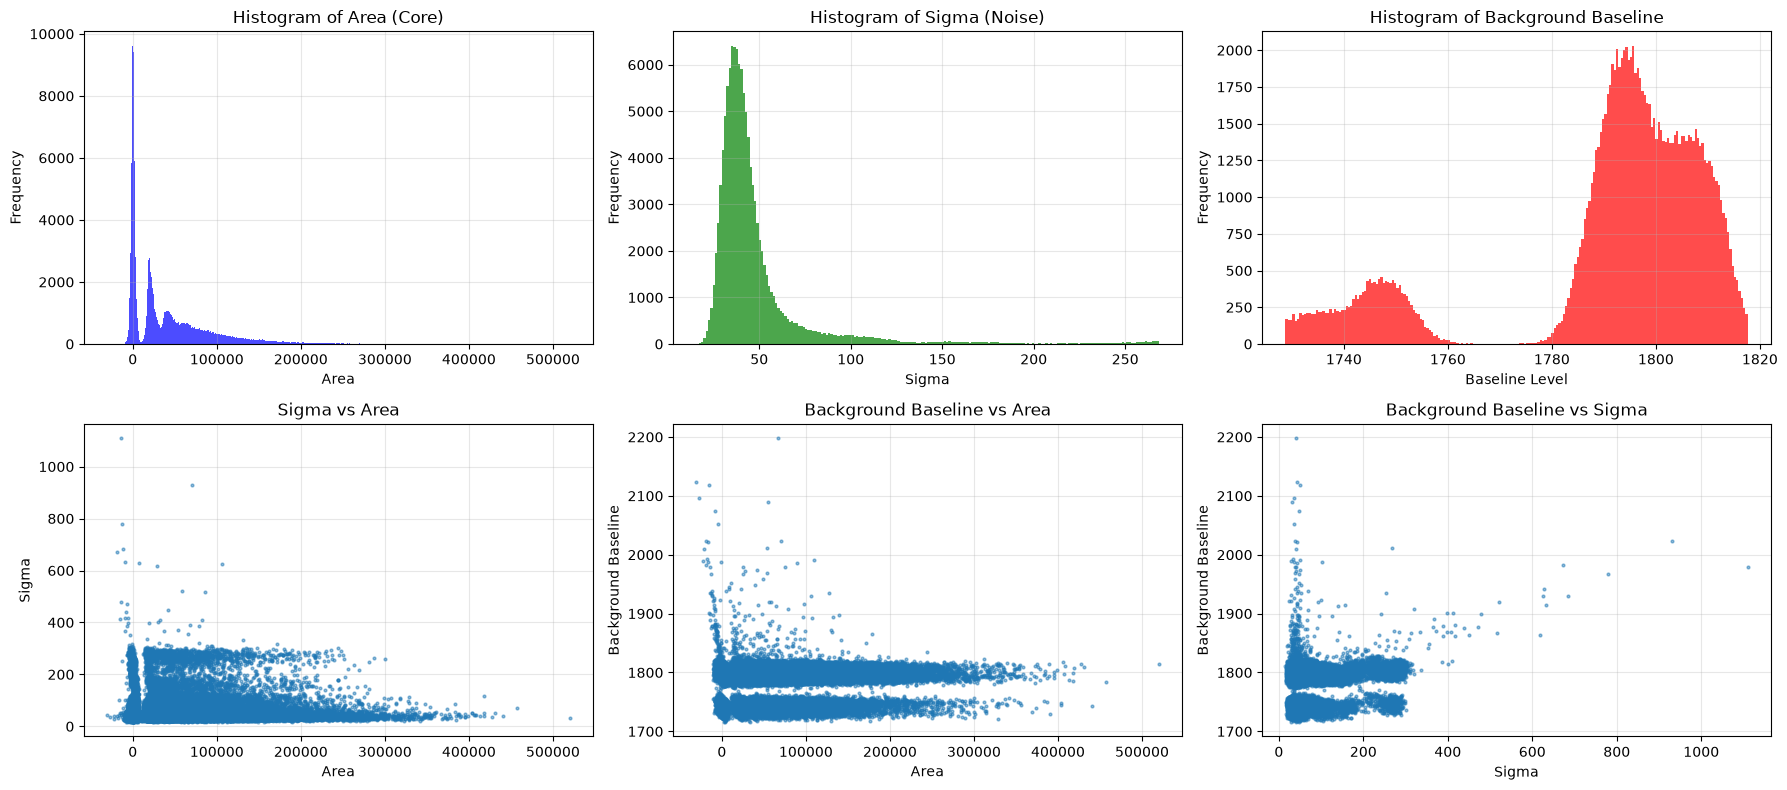

Processing 120065 data points...
Auto-detecting peaks...
Physics Curve fitting converged successfully!

--- Physical Fit Results ---
Pedestal (μ_0): 4.724521e+02
Detector Gain:      2.061598e+04
Pedestal Noise (σ_0): 1.780190e+03
1-Photon Noise (σ_1): 3.983060e+03
χ² / NDF:           49138.16 / 352 = 139.597
----------------------------
Peak 0: μ = 4.724521e+02, σ = 1.780190e+03
Peak 1: μ = 2.108843e+04, σ = 4.362779e+03
Peak 2: μ = 4.170442e+04, σ = 5.907505e+03
Peak 3: μ = 6.232040e+04, σ = 7.124843e+03
Peak 4: μ = 8.293638e+04, σ = 8.162607e+03
Peak 5: μ = 1.035524e+05, σ = 9.082561e+03
Peak 6: μ = 1.241683e+05, σ = 9.917544e+03
Peak 7: μ = 1.447843e+05, σ = 1.068749e+04


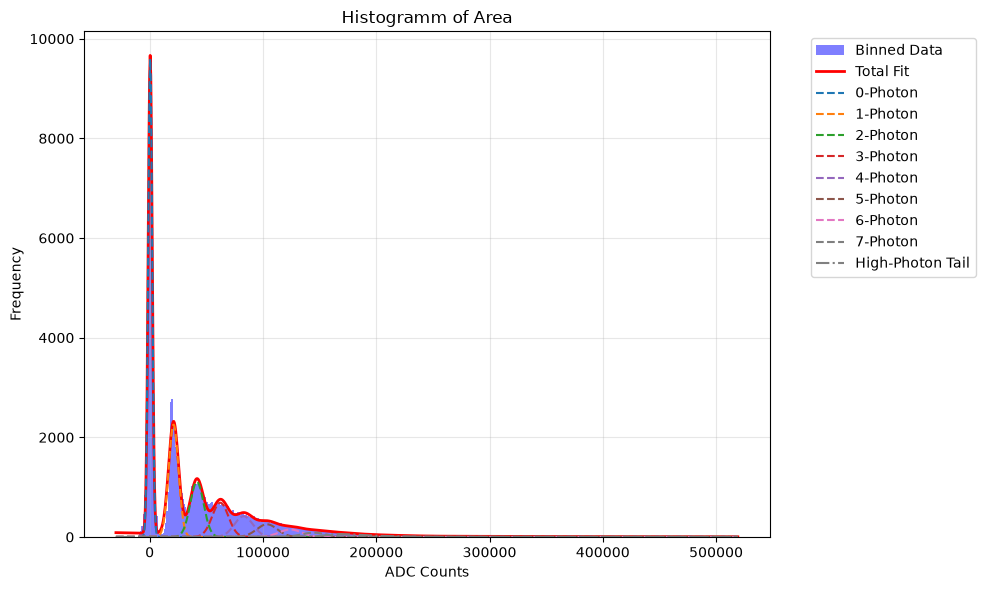

(array([7.21905810e+01, 6.05295034e-06, 4.72452137e+02, 1.78018962e+03,
        2.06159828e+04, 3.98306021e+03, 9.59413321e+03, 2.25629719e+03,
        1.10476357e+03, 6.87064505e+02, 4.15725916e+02, 2.53306952e+02,
        1.49510722e+02, 8.56236703e+01, 5.17712867e+01, 2.46502815e+01,
        1.22779416e+01, 5.08650066e+00, 6.23083173e-10, 7.56730826e-11,
        1.35632531e-14, 2.45305348e-12, 7.21166756e-14, 3.07030717e-15]),
 array([[ 2.69416995e+02, -7.04996928e-06,  1.36657039e+00,
         -7.04985069e+01,  1.36724377e+02, -4.59152722e+02,
         -1.89905056e+02, -2.11419437e+02, -2.00215930e+02,
         -1.67596764e+02, -1.45824650e+02, -1.29779971e+02,
         -1.15260601e+02, -1.01277640e+02, -8.92372278e+01,
         -7.86494228e+01, -6.73880135e+01, -6.20742967e+01,
         -4.80173035e+01, -5.30931757e+01, -2.60701794e+01,
         -5.75316053e+01,  3.83017741e+00, -6.71753004e+01],
        [-7.04996928e-06,  1.38585285e-11,  9.21701499e-07,
          1.85645457e-06,

In [7]:
array_area, array_sigma, array_bkg = nbk.compute_DAQ_data(filepaths[3])

nbk.plotter(array_area, array_sigma, array_bkg)

nbk.analyze_and_fit_physics(array_area,num_peaks_to_fit=18)


Total events: 120058
Rejected by Pile-up (Found >1 peak): 0
Rejected by bad window length: 0
Successfully integrated: 120058


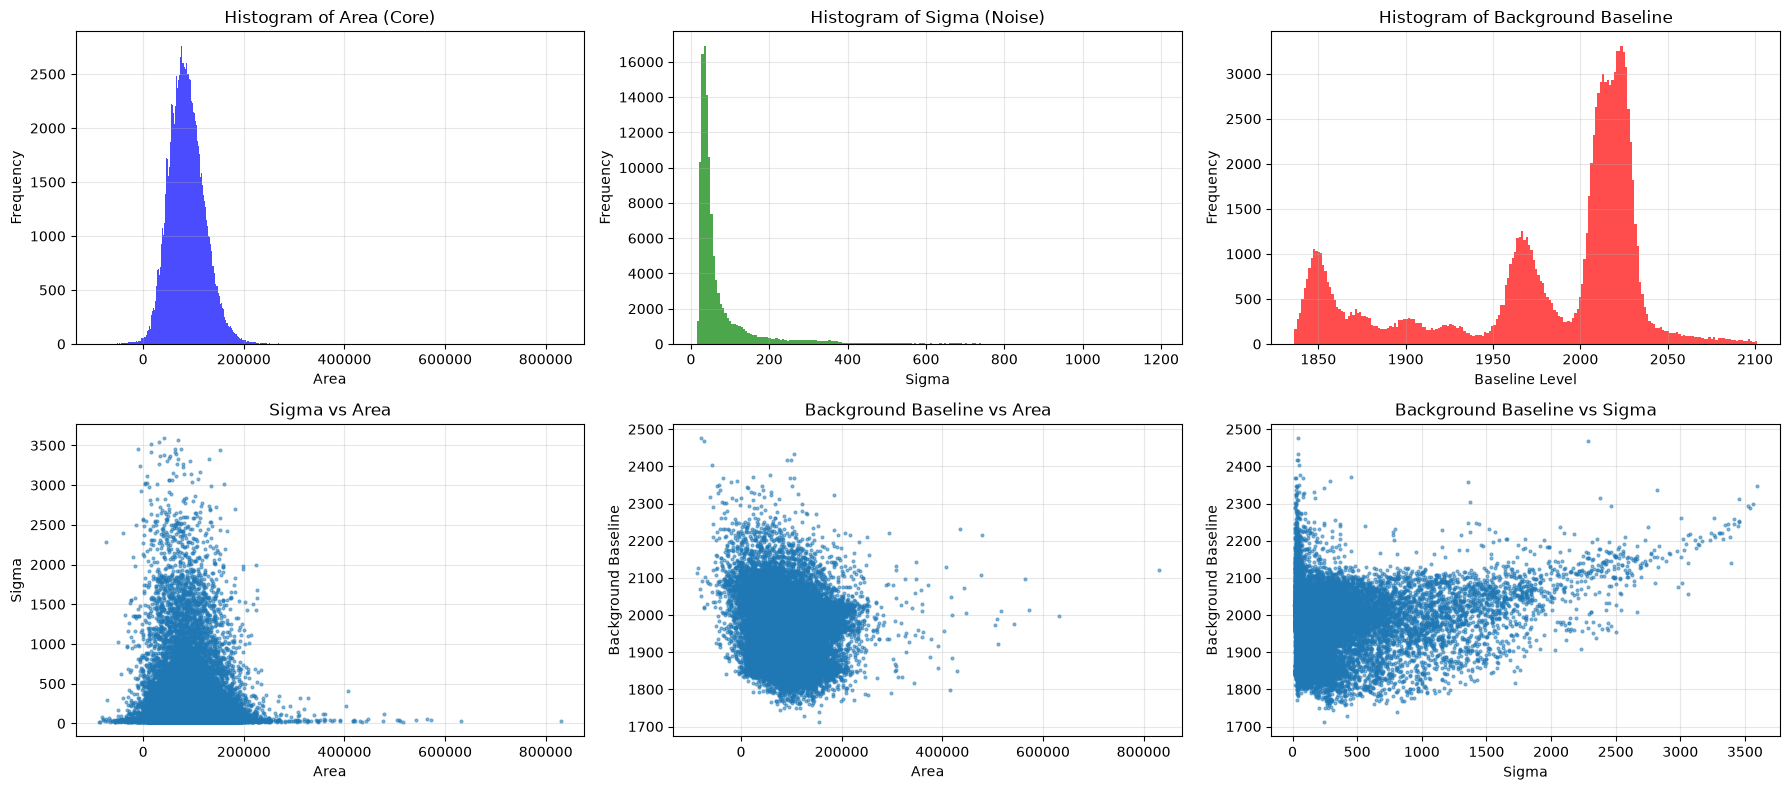

Processing 120058 data points...
Auto-detecting peaks...
Physics Curve fitting converged successfully!

--- Physical Fit Results ---
Pedestal (μ_0): 1.514180e+04
Detector Gain:      2.023069e+04
Pedestal Noise (σ_0): 1.069691e+04
1-Photon Noise (σ_1): 1.757423e+03
χ² / NDF:           1187.12 / 216 = 5.496
----------------------------
Peak 0: μ = 1.514180e+04, σ = 1.069691e+04
Peak 1: μ = 3.537250e+04, σ = 1.084032e+04
Peak 2: μ = 5.560319e+04, σ = 1.098185e+04
Peak 3: μ = 7.583388e+04, σ = 1.112158e+04
Peak 4: μ = 9.606457e+04, σ = 1.125958e+04
Peak 5: μ = 1.162953e+05, σ = 1.139591e+04
Peak 6: μ = 1.365260e+05, σ = 1.153062e+04
Peak 7: μ = 1.567566e+05, σ = 1.166378e+04


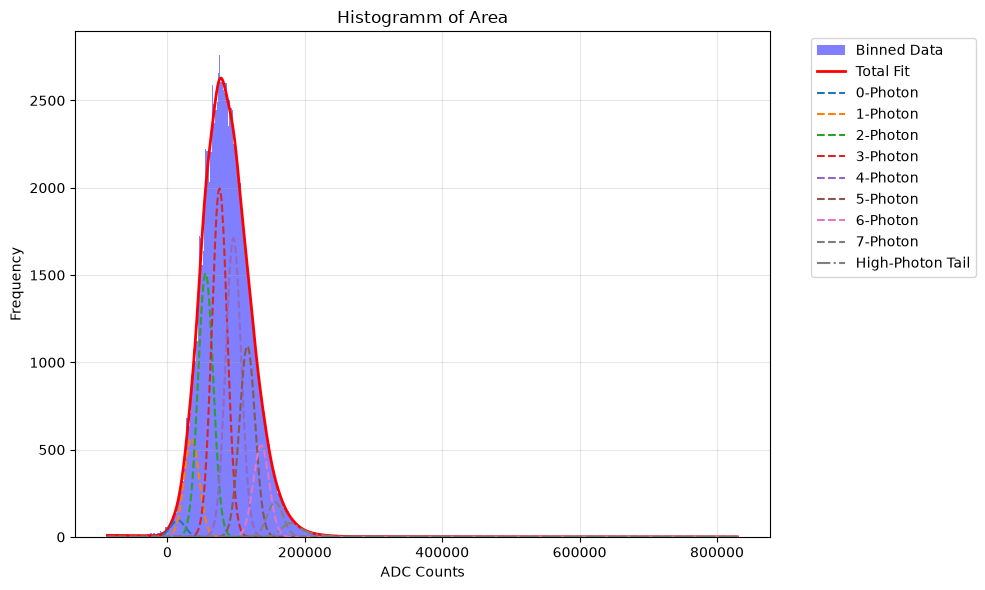

(array([6.16134828e+00, 4.18403824e-06, 1.51418039e+04, 1.06969150e+04,
        2.02306911e+04, 1.75742269e+03, 9.47545256e+01, 5.64875472e+02,
        1.50959883e+03, 1.99610522e+03, 1.71107484e+03, 1.09285571e+03,
        5.24802728e+02, 1.99951794e+02, 7.21251326e+01, 2.31136973e+01,
        7.91053793e+00, 2.90686481e+00, 3.02555606e-12, 1.45515988e-18,
        5.28075832e-22, 3.51028111e-25, 1.01390135e-25, 1.52546939e-26]),
 array([[ 1.61308029e+01, -6.75460027e-06,  3.51809429e+02,
         -6.32925719e+02, -3.09106038e+02,  9.12985896e+02,
         -4.43284973e+00,  9.87312860e+00, -1.34154127e+01,
         -1.54753830e+01, -4.93823248e+00,  5.70090899e+00,
          7.27763378e+00, -3.03209408e-01, -4.56719145e+00,
         -5.89988311e+00, -6.58734643e+00, -6.08127441e+00,
         -5.73992087e+00, -5.96918260e+00, -4.62444902e+00,
         -6.11877234e+00, -2.42367591e+00, -7.96150029e+00],
        [-6.75460027e-06,  3.49540630e-11, -1.27115797e-04,
          1.82858192e-04,

In [8]:
array_area, array_sigma, array_bkg = nbk.compute_DAQ_data(filepaths[4])

nbk.plotter(array_area, array_sigma, array_bkg)

nbk.analyze_and_fit_physics(array_area,num_peaks_to_fit=18)

Total events: 120092
Rejected by Pile-up (Found >1 peak): 0
Rejected by bad window length: 0
Successfully integrated: 120092


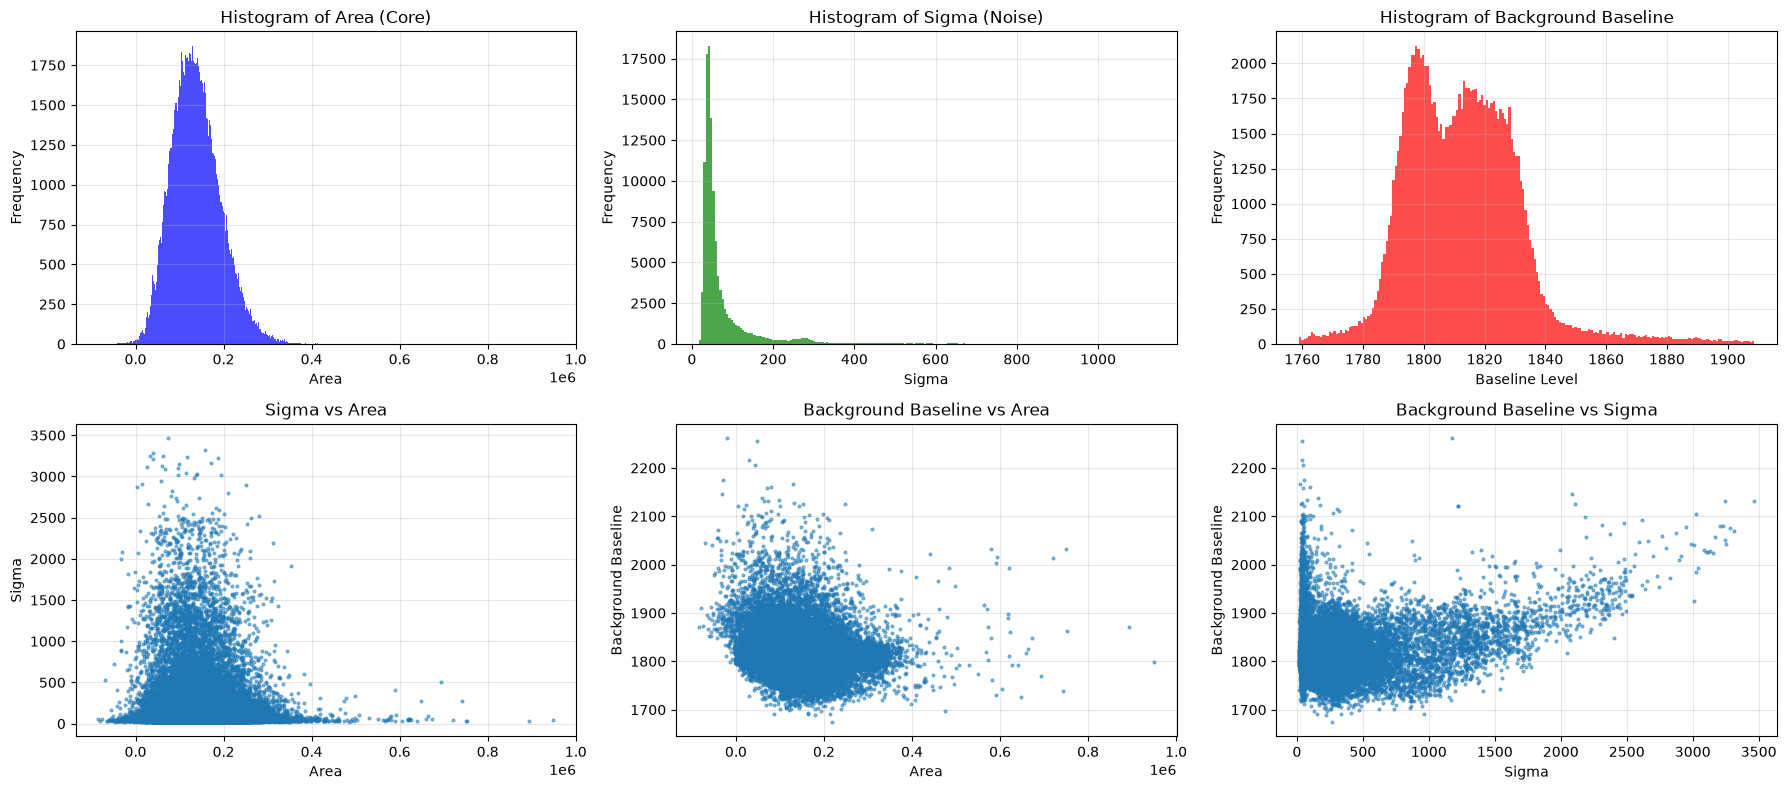

Processing 120092 data points...
Auto-detecting peaks...
Physics Curve fitting converged successfully!

--- Physical Fit Results ---
Pedestal (μ_0): 4.765511e+04
Detector Gain:      3.217530e+04
Pedestal Noise (σ_0): 1.941181e+04
1-Photon Noise (σ_1): 3.135499e-01
χ² / NDF:           560.23 / 264 = 2.122
----------------------------
Peak 0: μ = 4.765511e+04, σ = 1.941181e+04
Peak 1: μ = 7.983042e+04, σ = 1.941181e+04
Peak 2: μ = 1.120057e+05, σ = 1.941181e+04
Peak 3: μ = 1.441810e+05, σ = 1.941181e+04
Peak 4: μ = 1.763563e+05, σ = 1.941181e+04
Peak 5: μ = 2.085316e+05, σ = 1.941181e+04
Peak 6: μ = 2.407069e+05, σ = 1.941181e+04
Peak 7: μ = 2.728822e+05, σ = 1.941181e+04


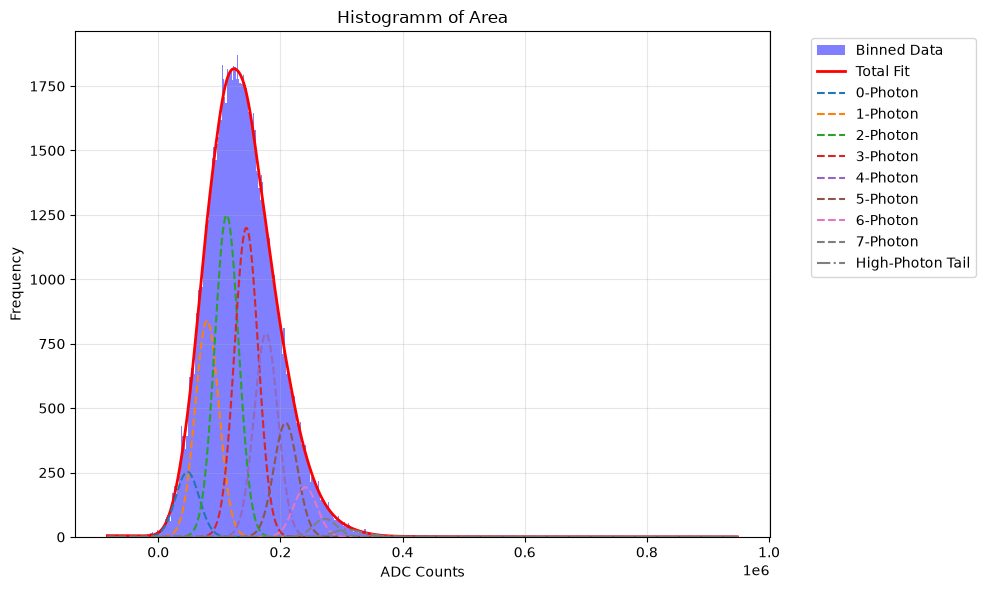

(array([3.83255668e+00, 3.17644185e-06, 4.76551148e+04, 1.94118116e+04,
        3.21753041e+04, 3.13549909e-01, 2.52316884e+02, 8.39191494e+02,
        1.24895129e+03, 1.19956023e+03, 7.89310882e+02, 4.42594691e+02,
        1.92596533e+02, 7.03596789e+01, 2.62725134e+01, 8.95334642e+00,
        1.58111748e+00, 7.91650372e-01, 1.69325081e-01, 5.29177870e-25,
        4.11252811e-33, 4.11554991e-33, 3.38712383e-32, 8.47273533e-34]),
 array([[ 8.56088289e+00, -4.29206006e-06,  1.59239232e+03,
         -6.65627910e+02, -6.43400968e+02, -1.27319605e+05,
          2.72635542e+01,  2.16683603e+01,  8.40511556e+00,
          1.11910908e+01,  2.07935576e+01,  1.83314842e+01,
          1.39650677e+01,  4.71837568e+00,  1.82316748e-01,
         -1.44332207e+00, -2.38273561e+00, -2.80821772e+00,
         -2.42007204e+00, -2.55251983e+00, -2.07225583e+00,
         -2.48738767e+00, -1.25329509e+00, -3.12305310e+00],
        [-4.29206006e-06,  3.82511470e-11, -9.41175753e-04,
          3.61694681e-04,

In [9]:
array_area, array_sigma, array_bkg = nbk.compute_DAQ_data(filepaths[5])

nbk.plotter(array_area, array_sigma, array_bkg)

nbk.analyze_and_fit_physics(array_area, num_peaks_to_fit=18)

Total events: 120061
Rejected by Pile-up (Found >1 peak): 0
Rejected by bad window length: 0
Successfully integrated: 120061


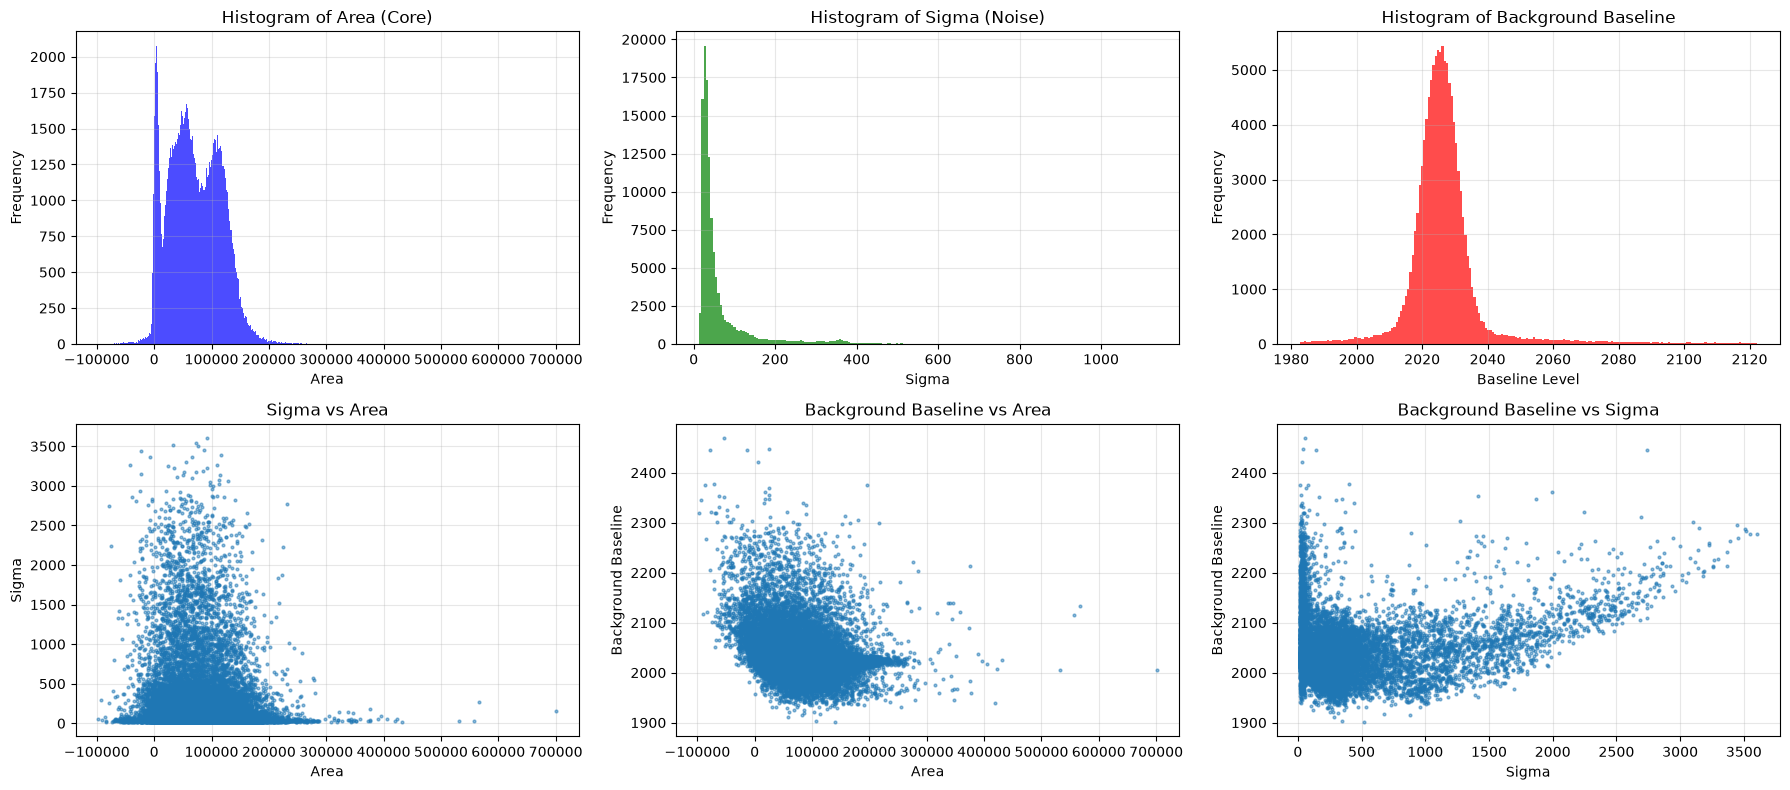

Processing 120061 data points...
Auto-detecting peaks...
Physics Curve fitting converged successfully!

--- Physical Fit Results ---
Pedestal (μ_0): 4.231635e+03
Detector Gain:      5.265706e+04
Pedestal Noise (σ_0): 1.595669e+03
1-Photon Noise (σ_1): 7.978343e+02
χ² / NDF:           1594482.20 / 237 = 6727.773
----------------------------
Peak 0: μ = 4.231635e+03, σ = 1.595669e+03
Peak 1: μ = 5.688870e+04, σ = 1.784012e+03
Peak 2: μ = 1.095458e+05, σ = 1.954287e+03
Peak 3: μ = 1.622028e+05, σ = 2.110871e+03


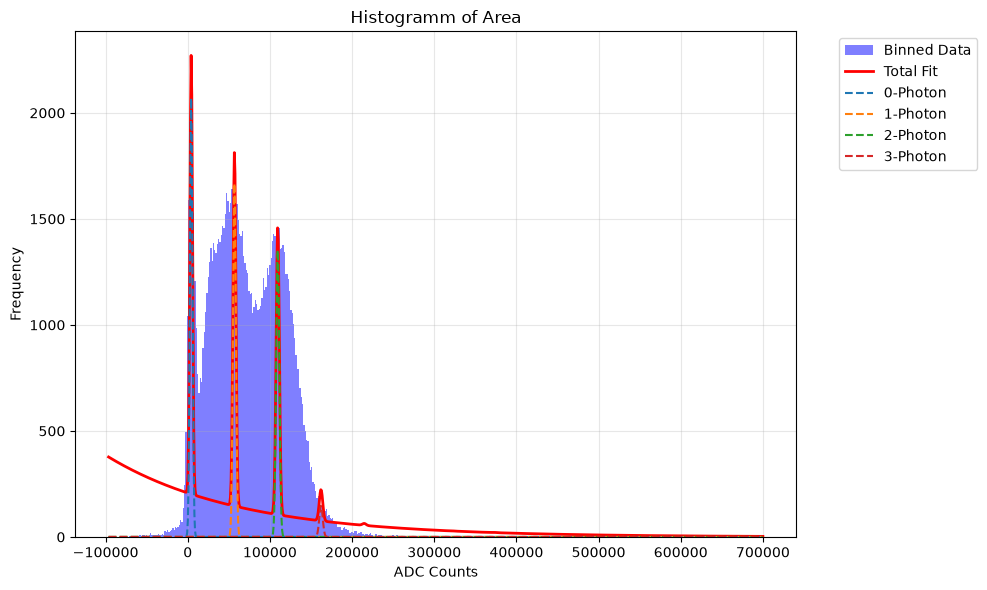

(array([2.07299998e+02, 6.21152588e-06, 4.23163544e+03, 1.59566866e+03,
        5.26570608e+04, 7.97834321e+02, 2.07300000e+03, 1.67300000e+03,
        1.36000000e+03, 1.48000000e+02, 9.00000000e+00, 1.00000000e-10,
        1.00000000e+00, 1.00000000e+00, 1.00000000e-10, 1.00000000e-10,
        1.00138657e-10, 1.00000000e-10, 1.00000000e-10, 1.00000000e-10,
        1.00000000e-09, 1.00000000e-09, 1.00000000e-09, 1.00000000e-09]),
 array([[ 1.42343163e+03, -2.36341617e-05,  1.29073046e+01,
         -1.47226440e+03,  9.80211566e+00, -1.21086799e+03,
         -1.03476907e+03, -8.19335903e+02, -6.41179396e+02,
         -1.05773183e+03, -9.15789878e+02, -7.33283567e+02,
         -5.77801694e+02, -4.52246230e+02, -3.52361971e+02,
         -2.72658776e+02, -2.09992489e+02, -1.61063318e+02,
         -1.23085807e+02, -9.37484913e+01,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [-2.36341617e-05,  5.11330113e-12,  3.05097389e-06,
          2.51251692e-05,

In [10]:
array_area, array_sigma, array_bkg = nbk.compute_DAQ_data(filepaths[6])

nbk.plotter(array_area, array_sigma, array_bkg)

nbk.analyze_and_fit_physics(array_area, num_peaks_to_fit=18)